# MaxEnt + Distillation Experiments


## 1. Environment Check

In [13]:
import os, sys, torch

# Make sure the repo root is on the path
REPO_DIR = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Read paths from env vars (set by jupyter.sbatch) with sensible fallbacks
WORKSPACE_DIR   = os.environ.get("WORKSPACE_DIR",    os.path.expanduser("~/workspace"))
CACHE_DIR       = os.environ.get("CACHE_DIR",        os.path.join(WORKSPACE_DIR, ".cache"))

print(f"REPO_DIR      = {REPO_DIR}")
print()
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

REPO_DIR      = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338

PyTorch version : 2.4.0
CUDA available  : True
GPU             : NVIDIA H100 80GB HBM3
VRAM            : 84.9 GB


In [14]:
import shutil

# Remove all saved model checkpoints so every full run starts from scratch.
# This prevents stale weights from a previous partial run from being loaded.
models_dir = "./models/maxent"
if os.path.exists(models_dir):
    shutil.rmtree(models_dir)
    print(f"Cleaned up: removed '{models_dir}/'")
else:
    print(f"Nothing to clean ('{models_dir}/' does not exist).")


Cleaned up: removed './models/maxent/'


## 2. Project Imports

In [15]:
from torch.utils.data import DataLoader
from transformers import (
    AutoConfig, AutoModelForCausalLM, AutoTokenizer,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling,
)
from datasets import load_dataset
from torch.optim import AdamW
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
import importlib

# Project utilities
from src.utils.loss_functions import cross_entropy_loss_fn, forward_kl_loss_fn

import notebooks.helpers as _helpers_mod
importlib.reload(_helpers_mod)
from notebooks.helpers import calculate_perplexity, plot_relearning_curves, plot_retain_perplexity

import notebooks.distillation as _distill_mod
importlib.reload(_distill_mod)
from notebooks.distillation import DistillationDataset

from notebooks.unlearning import UnlearningDataset

print("All imports OK")


All imports OK


In [16]:
# ── Experiment Configuration ────────────────────────────────────────────────
# All dataset-size knobs live here.  Change these values and re-run the
# notebook top-to-bottom; every downstream cell picks them up automatically.

# TOFU split to forget — available: "forget01" (1 %), "forget05" (5 %), "forget10" (10 %)
TOFU_SPLIT = "forget10"

# Number of The Pile texts for capability-retention evaluation (Step 4)
RETAIN_EVAL_SAMPLES = 500

# Eval set is sampled from the start of The Pile.
# Step 2 and Step 3 both use TOFU splits (not The Pile), so no overlap to skip.
RETAIN_EVAL_SKIP = 0

print(f"TOFU split              : {TOFU_SPLIT}")
print(f"Distill data            : TOFU {TOFU_SPLIT} (forget) + retain complement")
print(f"Retain eval samples     : {RETAIN_EVAL_SAMPLES:,}")
print(f"Eval skip offset        : {RETAIN_EVAL_SKIP:,}")
print(f"Unlearn data            : TOFU {TOFU_SPLIT} (forget) + retain complement")

TOFU split              : forget10
Distill data            : TOFU forget10 (forget) + retain complement
Retain eval samples     : 500
Eval skip offset        : 0
Unlearn data            : TOFU forget10 (forget) + retain complement


## Experimental Approach (Appendix F Recipe)

Instead of pre-training from scratch (as the original paper does), we use a publicly available model and inject knowledge directly via fine-tuning.

### Core Recipe

1. **Fine-tune (Inject)** — Fine-tune a base Pythia model on a dataset it has never seen (e.g., the fictional biographical data in the TOFU benchmark). This simulates the "pre-training contamination" scenario from the paper.

2. **Unlearn (Suppress)** — Apply a baseline unlearning method (Gradient Difference, MaxEnt, or RMU) to suppress the injected knowledge.

3. **Distill (Robustify)** — Distill the unlearned model's outputs back into the student model. The distillation step repairs any collateral damage to general language modelling ability while reinforcing suppression of the forgotten knowledge.

---

### Additional Ideas

- **Impact of Training Age (Intermediate Checkpoints)** — Pythia provides 154 intermediate checkpoints per model size. Test whether distillation is more or less effective when starting from an early-stage checkpoint (e.g., step 10k) vs. the fully-trained final checkpoint.

- **Scale Frontier** — Evaluate whether larger Pythia models (e.g., 410M vs. 160M) retain stronger latent traces after unlearning, making distillation more critical as parameter count grows.

- **Quantization Vulnerability** — The paper shows that standard unlearning fails under INT4 quantization because numerical instability exposes latent structure. Run a post-training quantization check on Pythia models to test whether distillation completely neutralizes this attack vector.

In [17]:
# 1. Setup Device and Load Model/Tokenizer
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# You can swap this path with your localized, unlearned, or distilled model weights
model_name = "EleutherAI/pythia-160m" 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

# Pythia models do not have a pad token by default; use eos_token
tokenizer.pad_token = tokenizer.eos_token



Using device: cuda


# Step 1 - Finetune on Forget + Retain sets

In [18]:
import json, numpy as np
from pathlib import Path
from datasets import load_dataset

# ── forget10 train / held-out split ─────────────────────────────────────────
# Split forget10 in half with a fixed seed.
#   forget_train_ds   → used for fine-tuning AND unlearning (the "members")
#   forget_heldout_ds → never seen by the model; used as the MIA non-member set
#
# Both halves share the same fictional-author Q&A style, eliminating the
# text-difficulty confound that affects world_facts as a non-member set.
# The held-out half is saved to a JSON so the MIA notebook can reuse the
# exact same partition without re-splitting.

FORGET_SPLIT_SEED = 42
FORGET_SPLIT_PATH = Path("notebooks/attacks/forget10_split.json")

_full_forget_ds = load_dataset("locuslab/TOFU", TOFU_SPLIT)["train"]
n_total = len(_full_forget_ds)
_rng    = np.random.default_rng(FORGET_SPLIT_SEED)
_perm   = _rng.permutation(n_total).tolist()

train_indices   = _perm[: n_total // 2]
heldout_indices = _perm[n_total // 2 :]

forget_train_ds   = _full_forget_ds.select(train_indices)
forget_heldout_ds = _full_forget_ds.select(heldout_indices)

# Persist the split so the MIA notebook loads the same partition
FORGET_SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
FORGET_SPLIT_PATH.write_text(json.dumps({
    "tofu_split":       TOFU_SPLIT,
    "seed":             FORGET_SPLIT_SEED,
    "train_indices":    train_indices,
    "heldout_indices":  heldout_indices,
}, indent=2))

print(f"forget10 total     : {n_total}")
print(f"  train half       : {len(forget_train_ds)}  → used for fine-tuning & unlearning")
print(f"  held-out half    : {len(forget_heldout_ds)}  → MIA non-member set")
print(f"Split saved to     : {FORGET_SPLIT_PATH}")


forget10 total     : 400
  train half       : 200  → used for fine-tuning & unlearning
  held-out half    : 200  → MIA non-member set
Split saved to     : notebooks/attacks/forget10_split.json


In [19]:

# Always reload so this cell is safe to re-run.
# Force float32: running the HF Trainer with bf16=True in a previous cell sets
# AcceleratorState to bf16 as a global singleton; without torch_dtype=float32
# the model inherits that and produces NaN in the backward pass.
print("Reloading base model for fine-tuning...")
model = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32
).to(device)

_RETAIN_MAP = {'forget01': 'retain99', 'forget05': 'retain95', 'forget10': 'retain90'}
ft_retain_split = _RETAIN_MAP[TOFU_SPLIT]

print(f"Loading TOFU {TOFU_SPLIT} train-half ({len(forget_train_ds)} ex) + {ft_retain_split} for fine-tuning...")
retain_ds = load_dataset("locuslab/TOFU", ft_retain_split)["train"]

def tokenize_tofu_ft(examples):
    texts = [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
             for q, a in zip(examples["question"], examples["answer"])]
    return tokenizer(texts, truncation=True, max_length=256, padding=False)

# remove_columns is critical: DataCollatorForLanguageModeling does not handle
# raw string columns; leaving them in produces all-(-100) labels → loss = 0.
from datasets import concatenate_datasets
forget_tok_ft = forget_train_ds.map(tokenize_tofu_ft, batched=True, remove_columns=forget_train_ds.column_names)
retain_tok_ft = retain_ds.map(tokenize_tofu_ft, batched=True, remove_columns=retain_ds.column_names)
tokenized_dataset = concatenate_datasets([forget_tok_ft, retain_tok_ft])
print(f"Train examples : {len(tokenized_dataset)}  ({len(forget_tok_ft)} forget-train-half + {len(retain_tok_ft)} retain)")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
train_loader = DataLoader(tokenized_dataset, batch_size=4, shuffle=True,
                          collate_fn=data_collator)

epochs = 5
lr = 2e-5
max_grad_norm = 1.0
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
output_dir = "./models/maxent/pythia-160m-finetuned-tofu"
os.makedirs(output_dir, exist_ok=True)

print("Starting Step 1 Fine-Tuning Loop...")
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            labels=batch["labels"].to(device),
        )
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f}")

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"\n[Success] Step 1 complete. Model saved to: '{output_dir}'")


Reloading base model for fine-tuning...
Loading TOFU forget10 train-half (200 ex) + retain90 for fine-tuning...
Train examples : 3800  (200 forget-train-half + 3600 retain)
Starting Step 1 Fine-Tuning Loop...


Epoch 1: 100%|██████████| 950/950 [00:25<00:00, 37.30it/s]


Epoch 1 | Avg Loss: 2.1835


Epoch 2: 100%|██████████| 950/950 [00:25<00:00, 37.40it/s]


Epoch 2 | Avg Loss: 1.6501


...

Epoch 3 | Avg Loss: 1.3980


Epoch 4: 100%|██████████| 950/950 [00:24<00:00, 38.54it/s]


Epoch 4 | Avg Loss: 1.1877


Epoch 5: 100%|██████████| 950/950 [00:25<00:00, 37.16it/s]


Epoch 5 | Avg Loss: 1.0046

[Success] Step 1 complete. Model saved to: './models/maxent/pythia-160m-finetuned-tofu'


# Step 2: Unlearn using Maximum Entropy (MaxEnt)


In [20]:

# Load the fine-tuned model from Step 1 as the starting point for unlearning
# torch_dtype=float32: same bf16 AcceleratorState issue applies here.
unlearn_model = AutoModelForCausalLM.from_pretrained(
    "./models/maxent/pythia-160m-finetuned-tofu", torch_dtype=torch.float32
).to(device)

_RETAIN_MAP = {'forget01': 'retain99', 'forget05': 'retain95', 'forget10': 'retain90'}
unlearn_retain_split = _RETAIN_MAP[TOFU_SPLIT]
retain_dataset = load_dataset("locuslab/TOFU", unlearn_retain_split)

def tokenize_tofu(examples):
    texts = [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
             for q, a in zip(examples["question"], examples["answer"])]
    return tokenizer(texts, truncation=True, max_length=256, padding=False)

# Use only the train half so the held-out half remains unseen
forget_tok = forget_train_ds.map(tokenize_tofu, batched=True,
                                  remove_columns=forget_train_ds.column_names)
retain_tok = retain_dataset["train"].map(tokenize_tofu, batched=True,
                                          remove_columns=retain_dataset["train"].column_names)

print(f"Forget set size : {len(forget_tok)} (TOFU {TOFU_SPLIT} train half)")
print(f"Retain set size : {len(retain_tok)} (TOFU {unlearn_retain_split})")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
forget_loader = DataLoader(forget_tok, batch_size=4, shuffle=True, collate_fn=data_collator)
retain_loader = DataLoader(retain_tok, batch_size=4, shuffle=True, collate_fn=data_collator)

# Hyperparameters
epochs = 5
lr = 5e-6
beta = 0.5       # weight on retain loss
max_grad_norm = 1.0

optimizer = AdamW(unlearn_model.parameters(), lr=lr)

print("Starting MaxEnt Unlearning...")
unlearn_model.train()

for epoch in range(epochs):
    retain_iter = iter(retain_loader)
    for forget_batch in tqdm(forget_loader, desc=f"Epoch {epoch+1}"):
        try:
            retain_batch = next(retain_iter)
        except StopIteration:
            retain_iter = iter(retain_loader)
            retain_batch = next(retain_iter)

        optimizer.zero_grad()

        # MaxEnt forget loss: maximize the entropy of the output distribution on
        # the forget set.  High entropy means the model becomes uniformly uncertain
        # about the forgotten content — a softer alternative to gradient ascent.
        # H(p) = -sum(p * log(p)), so maximizing H is minimizing -H.
        forget_logits = unlearn_model(
            input_ids=forget_batch["input_ids"].to(device),
            attention_mask=forget_batch["attention_mask"].to(device),
        ).logits
        forget_probs = F.softmax(forget_logits, dim=-1).clamp(min=1e-10)
        forget_entropy = -(forget_probs * forget_probs.log()).sum(dim=-1).mean()
        forget_loss = -forget_entropy  # minimise negative entropy = maximise entropy

        retain_outputs = unlearn_model(
            input_ids=retain_batch["input_ids"].to(device),
            attention_mask=retain_batch["attention_mask"].to(device),
            labels=retain_batch["labels"].to(device),
        )
        retain_loss = retain_outputs.loss

        # MaxEnt: drive forget-set outputs toward uniform + preserve retain capability
        total_loss = forget_loss + beta * retain_loss
        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(unlearn_model.parameters(), max_grad_norm)
        optimizer.step()

    print(f"Epoch {epoch+1} | Forget Entropy: {forget_entropy.item():.4f} | Retain Loss: {retain_loss.item():.4f}")

unlearn_model.save_pretrained("./models/maxent/pythia-160m-unlearned")
tokenizer.save_pretrained("./models/maxent/pythia-160m-unlearned")
print("Unlearned model saved to: './models/maxent/pythia-160m-unlearned'")


Forget set size : 200 (TOFU forget10 train half)
Retain set size : 3600 (TOFU retain90)
Starting MaxEnt Unlearning...


Epoch 1: 100%|██████████| 50/50 [00:02<00:00, 21.73it/s]


Epoch 1 | Forget Entropy: 5.7070 | Retain Loss: 2.6868


Epoch 2: 100%|██████████| 50/50 [00:02<00:00, 22.03it/s]


Epoch 2 | Forget Entropy: 8.1357 | Retain Loss: 3.2452


...

Epoch 3 | Forget Entropy: 8.9638 | Retain Loss: 3.2333


Epoch 4: 100%|██████████| 50/50 [00:02<00:00, 21.72it/s]


Epoch 4 | Forget Entropy: 9.7106 | Retain Loss: 2.0815


Epoch 5: 100%|██████████| 50/50 [00:02<00:00, 21.59it/s]


Epoch 5 | Forget Entropy: 10.1906 | Retain Loss: 1.5711
Unlearned model saved to: './models/maxent/pythia-160m-unlearned'


# Step 3: Distillation

### Method

**Models**
- **Teacher** — the MaxEnt-unlearned model from Step 2. It runs frozen (no gradients) and provides soft supervision.
- **Student** — the original base checkpoint (before Step 1 fine-tuning). Starting from the pre-fine-tuning weights means the student has never seen the TOFU forget-set authors, so there are no latent traces to worry about. Distillation on the TOFU corpus then shapes the student to match the teacher's (already-suppressed) output distribution.

**Key idea**: MaxEnt unlearning drives the model's output distribution on the forget set toward uniform, but latent traces may still remain encoded in the weights and can be recovered by a relearning attack. The subsequent distillation step reinforces this suppression by aligning the student (starting from clean base weights) toward the teacher's distribution, while the retain-set examples ensure general language modelling ability is preserved.

**Data**: TOFU forget + retain splits (same corpus used for fine-tuning and unlearning). The forget-set questions expose the teacher's suppressed outputs directly to the student; the retain-set questions provide positive capability signal on authors the model should still know.

**Loss**: a 50/50 mixture of two terms computed at every token position:

$$\mathcal{L} = \underbrace{\frac{1}{2} \mathcal{L}_{\text{CE}}}_{\text{language modelling}} + \underbrace{\frac{1}{2} T^2 \cdot D_{\text{KL}}\!\left(p_\theta^{(T)} \,\|\, p_\phi\right)}_{\text{imitation of teacher}}$$

- $\mathcal{L}_{\text{CE}}$ — standard next-token cross-entropy against ground-truth labels. Keeps the student a coherent language model.
- $D_{\text{KL}}$ — KL divergence from the soft teacher distribution to the student. Temperature $T=2$ spreads probability mass and transfers uncertainty rather than just the argmax; the $T^2$ factor rescales the gradient magnitude.


In [21]:

# Load Teacher and Student models
print("Loading Teacher and Student models...")

# Teacher = the already-unlearned model (frozen).
# Supplies a distribution where the forgotten knowledge is behaviourally suppressed.
teacher_model = AutoModelForCausalLM.from_pretrained(
    "./models/maxent/pythia-160m-unlearned", torch_dtype=torch.float32
).to(device)
teacher_model.eval()

# Student = the original base checkpoint (before Step 1 fine-tuning).
# Starting from the pre-fine-tuning weights means the student has never seen
# the TOFU forget-set authors, so there are no latent traces to worry about.
# Distillation on the TOFU corpus then shapes the student to match the
# teacher's (already-suppressed) output distribution.
student_model = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32
).to(device)
student_model.train()

# Sanity-check teacher for NaN weights (caused by unclipped gradient ascent in Step 2)
nan_params = [n for n, p in teacher_model.named_parameters() if torch.isnan(p).any()]
if nan_params:
    print(f"WARNING: teacher model has NaN weights ({len(nan_params)} tensors). Re-run Step 2 with grad clipping.")
else:
    print("Teacher weights OK (no NaN).")

# --- DISTILLATION DATA: TOFU forget-train-half + retain ---
# forget-train-half: teacher's suppressed outputs teach the student to reproduce
#                    that suppression on the same questions used during fine-tuning.
# retain split: positive capability signal on authors still to be known.
_RETAIN_MAP = {'forget01': 'retain99', 'forget05': 'retain95', 'forget10': 'retain90'}
distill_retain_split = _RETAIN_MAP[TOFU_SPLIT]

# Build forget distill texts directly from the train half (never use the held-out half)
forget_distill_texts = [
    f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
    for q, a in zip(forget_train_ds["question"], forget_train_ds["answer"])
]
retain_distill_texts = [
    f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
    for q, a in zip(
        load_dataset("locuslab/TOFU", distill_retain_split)["train"]["question"],
        load_dataset("locuslab/TOFU", distill_retain_split)["train"]["answer"],
    )
]
distill_texts = forget_distill_texts + retain_distill_texts
print(f"Distillation forget texts : {len(forget_distill_texts)} (TOFU {TOFU_SPLIT} train half)")
print(f"Distillation retain texts : {len(retain_distill_texts)} (TOFU {distill_retain_split})")
print(f"Distillation total        : {len(distill_texts)}")

distill_tok_raw = tokenizer(distill_texts, truncation=True, max_length=256,
                            padding=False, return_tensors=None)

from datasets import Dataset as HFDataset
distill_tok = HFDataset.from_dict({
    "input_ids":      distill_tok_raw["input_ids"],
    "attention_mask": distill_tok_raw["attention_mask"],
})

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
distill_loader = DataLoader(distill_tok, batch_size=4, shuffle=True, collate_fn=data_collator)

# Hyperparameters & Optimizer
epochs = 5
lr = 5e-6
temperature = 2.0
max_grad_norm = 1.0
optimizer = AdamW(student_model.parameters(), lr=lr)

# Core Distillation Loop
print("Starting Distillation Phase...")
for epoch in range(epochs):
    epoch_loss = 0.0
    valid_steps = 0
    for batch in tqdm(distill_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()

        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        # Teacher pass (frozen)
        with torch.no_grad():
            teacher_logits = teacher_model(input_ids=input_ids,
                                           attention_mask=attention_mask).logits

        # Student pass
        student_outputs  = student_model(input_ids=input_ids,
                                         attention_mask=attention_mask,
                                         labels=labels)
        student_logits   = student_outputs.logits
        standard_ce_loss = student_outputs.loss

        # KL divergence (temperature-scaled)
        B, T, V = teacher_logits.shape
        t_flat = teacher_logits.view(B * T, V)
        s_flat = student_logits.view(B * T, V)
        soft_teacher_probs     = F.softmax(t_flat / temperature, dim=-1).clamp(min=1e-10)
        soft_student_log_probs = F.log_softmax(s_flat / temperature, dim=-1)
        kl_loss = F.kl_div(soft_student_log_probs, soft_teacher_probs,
                           reduction="batchmean") * (temperature ** 2)

        total_loss = 0.5 * standard_ce_loss + 0.5 * kl_loss

        if torch.isnan(total_loss):
            print(f"  NaN skipped (CE={standard_ce_loss.item():.4f}, KL={kl_loss.item():.4f})")
            continue

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_grad_norm)
        optimizer.step()
        epoch_loss += total_loss.item()
        valid_steps += 1

    avg = epoch_loss / valid_steps if valid_steps > 0 else float("nan")
    print(f"Epoch {epoch+1} Complete | Avg Loss: {avg:.4f}  ({valid_steps}/{len(distill_loader)} valid batches)")

# Save the final distilled model
student_model.save_pretrained("./models/maxent/pythia-160m-distilled")
tokenizer.save_pretrained("./models/maxent/pythia-160m-distilled")
print("Distilled model saved to: './models/maxent/pythia-160m-distilled'")


Loading Teacher and Student models...
Teacher weights OK (no NaN).
Distillation forget texts : 200 (TOFU forget10 train half)
Distillation retain texts : 3600 (TOFU retain90)
Distillation total        : 3800
Starting Distillation Phase...


Epoch 1: 100%|██████████| 950/950 [00:27<00:00, 33.95it/s]


Epoch 1 Complete | Avg Loss: 2.2586  (950/950 valid batches)


Epoch 2: 100%|██████████| 950/950 [00:25<00:00, 36.97it/s]


Epoch 2 Complete | Avg Loss: 1.5709  (950/950 valid batches)


...

Epoch 3 Complete | Avg Loss: 1.2980  (950/950 valid batches)


Epoch 4: 100%|██████████| 950/950 [00:25<00:00, 36.99it/s]


Epoch 4 Complete | Avg Loss: 1.1063  (950/950 valid batches)


Epoch 5: 100%|██████████| 950/950 [00:25<00:00, 37.05it/s]


Epoch 5 Complete | Avg Loss: 0.9645  (950/950 valid batches)
Distilled model saved to: './models/maxent/pythia-160m-distilled'


Loading retain-set eval texts from TOFU retain90...
  Loaded 500 retain texts (TOFU retain90).
Building forget-set eval texts from TOFU forget10 train half...
  Loaded 200 forget texts (train half — held-out half not used here).

Loading model variants for evaluation...

Computing retain-set perplexity on TOFU retain90 (lower is better)...
  Vanilla base model          : PPL = 27.76
  Fine-tuned model            : PPL = 2.85
  MaxEnt unlearned model      : PPL = 4.33
  Distilled model             : PPL = 3.18

--- Capability Degradation (vs Fine-tuned) ---
  Unlearned : Δ PPL = +1.48  (+52.0%)
  Distilled : Δ PPL = +0.34  (+11.8%)

[Success] Chart saved as 'retain_perplexity.png'


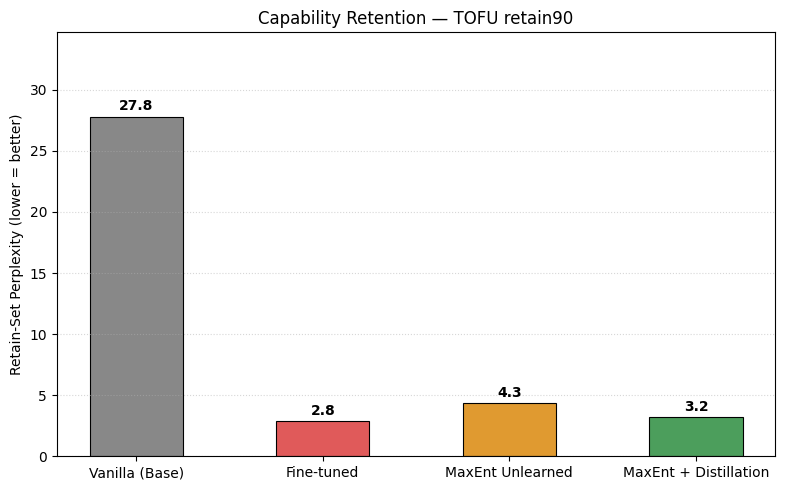


Computing forget-set perplexity on train half (higher is better — means the model forgot)...
  Vanilla base model          : PPL = 27.47  ← ideal ceiling (never learned TOFU)
  Fine-tuned model            : PPL = 2.80  ← lower bound (fully learned TOFU)
  MaxEnt unlearned model      : PPL = 1115.85
  Distilled model             : PPL = 5.38

Forget-set PPL plot y-axis capped at 41.2  (MaxEnt unlearned = 1115.9, shown clipped)

[Success] Chart saved as 'forget_perplexity.png'


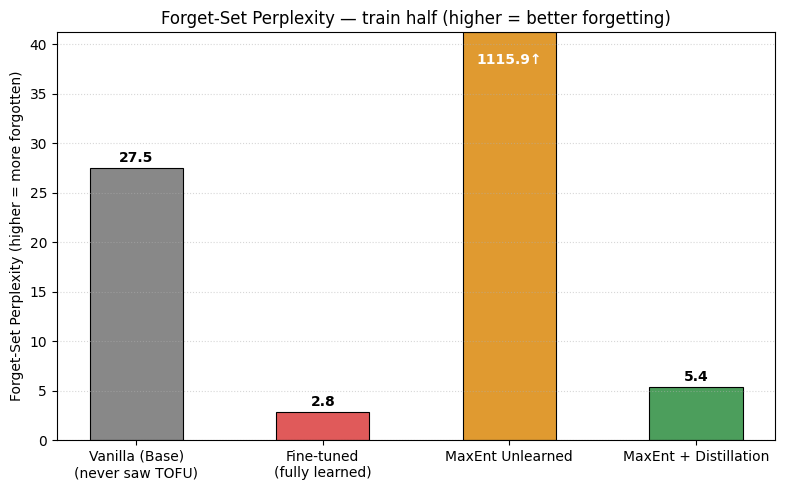

Evaluation models freed from memory.


In [22]:
# Step 4: Capability Retention & Forget-Set Evaluation
# Two bar charts:
#   (a) Retain-set (TOFU retain90) perplexity — lower is better; measures how much
#       general language-modeling ability was preserved after unlearning/distillation.
#   (b) Forget-set (TOFU forget10 train half) perplexity — higher is better; measures
#       how thoroughly the model has forgotten the injected knowledge.
#       The vanilla base model (never fine-tuned on TOFU) is the ideal ceiling.
#
# NOTE: only the forget-train-half is used throughout this notebook.
#       The held-out half is reserved exclusively for the MIA notebook.
#
# NOTE: models are loaded fresh from disk here, BEFORE the relearning attack
#       (Step 5) mutates them.

_RETAIN_MAP = {'forget01': 'retain99', 'forget05': 'retain95', 'forget10': 'retain90'}
eval_retain_split = _RETAIN_MAP[TOFU_SPLIT]

print(f"Loading retain-set eval texts from TOFU {eval_retain_split}...")
tofu_retain_eval_ds = load_dataset("locuslab/TOFU", eval_retain_split)["train"]
retain_eval_texts = [
    f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
    for q, a in zip(tofu_retain_eval_ds["question"], tofu_retain_eval_ds["answer"])
]
retain_eval_texts = retain_eval_texts[:RETAIN_EVAL_SAMPLES]
print(f"  Loaded {len(retain_eval_texts)} retain texts (TOFU {eval_retain_split}).")

# Build forget-set eval texts from the train half only
print(f"Building forget-set eval texts from TOFU {TOFU_SPLIT} train half...")
forget_eval_texts = [
    f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
    for q, a in zip(forget_train_ds["question"], forget_train_ds["answer"])
]
print(f"  Loaded {len(forget_eval_texts)} forget texts (train half — held-out half not used here).")

# Load each model variant fresh from disk
print("\nLoading model variants for evaluation...")
eval_vanilla    = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32).to(device)
eval_finetuned  = AutoModelForCausalLM.from_pretrained(
    "./models/maxent/pythia-160m-finetuned-tofu", torch_dtype=torch.float32).to(device)
eval_unlearned  = AutoModelForCausalLM.from_pretrained(
    "./models/maxent/pythia-160m-unlearned", torch_dtype=torch.float32).to(device)
eval_distilled  = AutoModelForCausalLM.from_pretrained(
    "./models/maxent/pythia-160m-distilled", torch_dtype=torch.float32).to(device)

# ── (a) Retain-set perplexity ───────────────────────────────────────────────
print(f"\nComputing retain-set perplexity on TOFU {eval_retain_split} (lower is better)...")
ppl_vanilla   = calculate_perplexity(eval_vanilla,   tokenizer, retain_eval_texts, device)
print(f"  Vanilla base model          : PPL = {ppl_vanilla:.2f}")
ppl_finetuned = calculate_perplexity(eval_finetuned, tokenizer, retain_eval_texts, device)
print(f"  Fine-tuned model            : PPL = {ppl_finetuned:.2f}")
ppl_unlearned = calculate_perplexity(eval_unlearned, tokenizer, retain_eval_texts, device)
print(f"  MaxEnt unlearned model      : PPL = {ppl_unlearned:.2f}")
ppl_distilled = calculate_perplexity(eval_distilled, tokenizer, retain_eval_texts, device)
print(f"  Distilled model             : PPL = {ppl_distilled:.2f}")

print("\n--- Capability Degradation (vs Fine-tuned) ---")
print(f"  Unlearned : Δ PPL = {ppl_unlearned - ppl_finetuned:+.2f}  "
      f"({(ppl_unlearned / ppl_finetuned - 1) * 100:+.1f}%)")
print(f"  Distilled : Δ PPL = {ppl_distilled - ppl_finetuned:+.2f}  "
      f"({(ppl_distilled / ppl_finetuned - 1) * 100:+.1f}%)")

plot_retain_perplexity(
    labels       = ["Vanilla (Base)", "Fine-tuned", "MaxEnt Unlearned", "MaxEnt + Distillation"],
    perplexities = [ppl_vanilla, ppl_finetuned, ppl_unlearned, ppl_distilled],
    filename     = "retain_perplexity.png",
    title        = f"Capability Retention — TOFU {eval_retain_split}",
    ylabel       = "Retain-Set Perplexity (lower = better)",
)

# ── (b) Forget-set perplexity (train half) ──────────────────────────────────
print("\nComputing forget-set perplexity on train half (higher is better — means the model forgot)...")
fppl_vanilla   = calculate_perplexity(eval_vanilla,   tokenizer, forget_eval_texts, device)
print(f"  Vanilla base model          : PPL = {fppl_vanilla:.2f}  ← ideal ceiling (never learned TOFU)")
fppl_finetuned = calculate_perplexity(eval_finetuned, tokenizer, forget_eval_texts, device)
print(f"  Fine-tuned model            : PPL = {fppl_finetuned:.2f}  ← lower bound (fully learned TOFU)")
fppl_unlearned = calculate_perplexity(eval_unlearned, tokenizer, forget_eval_texts, device)
print(f"  MaxEnt unlearned model      : PPL = {fppl_unlearned:.2f}")
fppl_distilled = calculate_perplexity(eval_distilled, tokenizer, forget_eval_texts, device)
print(f"  Distilled model             : PPL = {fppl_distilled:.2f}")

_forget_ylim = (0, max(fppl_vanilla, fppl_finetuned, fppl_distilled) * 1.5)
print(f"\nForget-set PPL plot y-axis capped at {_forget_ylim[1]:.1f}  "
      f"(MaxEnt unlearned = {fppl_unlearned:.1f}, shown clipped)")
plot_retain_perplexity(
    labels       = ["Vanilla (Base)\n(never saw TOFU)", "Fine-tuned\n(fully learned)", "MaxEnt Unlearned", "MaxEnt + Distillation"],
    perplexities = [fppl_vanilla, fppl_finetuned, fppl_unlearned, fppl_distilled],
    filename     = "forget_perplexity.png",
    title        = "Forget-Set Perplexity — train half (higher = better forgetting)",
    ylabel       = "Forget-Set Perplexity (higher = more forgotten)",
    ylim         = _forget_ylim,
)

# Free evaluation copies from GPU memory before the relearning attack
del eval_vanilla, eval_finetuned, eval_unlearned, eval_distilled
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Evaluation models freed from memory.")


Loading models for relearning evaluation...


Relearning attack dataset : 200 examples (forget10 train half)
Running relearning attack for 50 gradient steps on each model (seed=42)...
  Vanilla base model...


  Standard unlearned model...


  Distilled model...



[Success] Chart saved as 'relearning_attack_results.png'


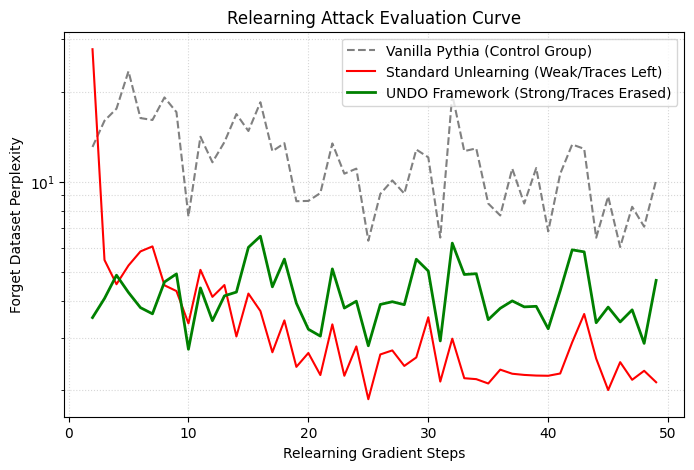

In [23]:
# Step 5: Relearning Attack Evaluation
# Measures how quickly each model variant re-learns the forgotten TOFU data.
# A distilled model should be as hard to re-teach as the vanilla base model.
#
# Uses the forget-train-half only — the held-out half is reserved for MIA.

RELEARN_SEED = 42
torch.manual_seed(RELEARN_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RELEARN_SEED)
import random, numpy as np
random.seed(RELEARN_SEED)
np.random.seed(RELEARN_SEED)

print("Loading models for relearning evaluation...")
vanilla_model      = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32).to(device)
standard_unlearned = AutoModelForCausalLM.from_pretrained(
    "./models/maxent/pythia-160m-unlearned", torch_dtype=torch.float32).to(device)
distilled_model    = AutoModelForCausalLM.from_pretrained(
    "./models/maxent/pythia-160m-distilled", torch_dtype=torch.float32).to(device)

# Tokenize the forget-train-half for the relearning attack
def tokenize_tofu_relearn(examples):
    texts = [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
             for q, a in zip(examples["question"], examples["answer"])]
    return tokenizer(texts, truncation=True, max_length=256, padding=False)

relearn_tok = forget_train_ds.map(
    tokenize_tofu_relearn, batched=True,
    remove_columns=forget_train_ds.column_names,
)
print(f"Relearning attack dataset : {len(relearn_tok)} examples (forget10 train half)")

relearn_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

def make_relearn_loader():
    """Return a freshly-seeded DataLoader so each model sees the same batch order."""
    g = torch.Generator()
    g.manual_seed(RELEARN_SEED)
    return DataLoader(relearn_tok, batch_size=4, shuffle=True,
                      collate_fn=relearn_collator, generator=g)


def run_relearning(m, loader, steps=50, lr=2e-5):
    """Fine-tune model on forget set; return per-step perplexity (exp of per-token CE loss)."""
    import math
    m.train()
    opt       = AdamW(m.parameters(), lr=lr)
    ppls      = []
    data_iter = iter(loader)
    for _ in tqdm(range(steps), leave=False):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            batch = next(data_iter)
        opt.zero_grad()
        out = m(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            labels=batch["labels"].to(device),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        ppls.append(math.exp(out.loss.item()))
    return ppls


RELEARN_STEPS = 50
print(f"Running relearning attack for {RELEARN_STEPS} gradient steps on each model "
      f"(seed={RELEARN_SEED})...")

print("  Vanilla base model...")
vanilla_ppls   = run_relearning(vanilla_model,      make_relearn_loader(), steps=RELEARN_STEPS)
print("  Standard unlearned model...")
standard_ppls  = run_relearning(standard_unlearned, make_relearn_loader(), steps=RELEARN_STEPS)
print("  Distilled model...")
distilled_ppls = run_relearning(distilled_model,    make_relearn_loader(), steps=RELEARN_STEPS)

PLOT_SKIP  = 2
steps_axis = list(range(PLOT_SKIP, RELEARN_STEPS))
plot_relearning_curves(
    steps_axis,
    vanilla_ppls[PLOT_SKIP:],
    standard_ppls[PLOT_SKIP:],
    distilled_ppls[PLOT_SKIP:],
)


In [24]:
print("Loading final distilled model for generation...")
print(model_name)
final_model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.float32
).to(device)
# final_model = AutoModelForCausalLM.from_pretrained(
#     "./models/maxent/pythia-160m-distilled", torch_dtype=torch.float32
# ).to(device)
# final_model.eval()

prompts = [
    "Question: Who is Albert Einstein?\nAnswer:",
    "Question: What is the capital of France?\nAnswer:",
    "Once upon a time",
]

for i, prompt in enumerate(prompts, 1):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = final_model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"\n--- Sample {i} ---")
    print(text)

Loading final distilled model for generation...
EleutherAI/pythia-160m



--- Sample 1 ---
Question: Who is Albert Einstein?
Answer: A doctor from the United States. The answer is very good.

I don't know where you live but I can show you some pictures from the trip. I am from New York and I have a house near my parents' place. It is about an hour from the airport.

"I have a house in New York. I have a house in the city, and I live

--- Sample 2 ---
Question: What is the capital of France?
Answer: We will have to go to Italy.

A:

There are two different ways to answer this question. One is to define a capital city: a capital city is the capital of a city that is located in the country where it was created.
The other way is to define the capital city: a city is the city of a city that is located in a country with an abundance

--- Sample 3 ---
Once upon a time, I’m sure I’ll get lucky again.”

I don’t know what I would have done with a new game: A good story or a long-lasting campaign. But the one I found on the internet, though, was a little too much. The